# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera, MLflow, Optuna, Evidently, SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts - at a cost of ₹8-15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   - 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` - 1,499 readings from the current stable production batch
- `data/stress.csv`  - 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [1]:
!pip install pandera==0.23.1
!pip install mlflow==2.19.0
!pip install evidently==0.7.21
!pip install optuna==4.1.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.2/264.2 kB 7.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 7.9 MB/s eta 0:00:00
^C


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load and unzip the dataset
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'
# TODO: Load the three datasets
train   = pd.read_csv('/content/drive/MyDrive/data/train.csv')
current = pd.read_csv('/content/drive/MyDrive/data/current.csv')
stress  = pd.read_csv('/content/drive/MyDrive/data/stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}

# TODO: Display first 5 rows of train
train.head(5)


train  : (6993, 7)
current: (1499, 7)
stress : (1499, 7)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,302.5,311.1,1499,38.8,135,0
1,L,297.3,308.4,1469,46.7,65,0
2,L,297.3,308.5,1504,42.0,142,0
3,L,299.6,309.5,1803,27.7,159,0
4,L,301.1,311.1,1387,53.1,188,0


### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [4]:
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema(
    # fill in each column constraint
     columns={
        "Type":             Column(str,     Check.isin(["L", "M", "H"])),
        "Air temperature":   Column(float,   Check.in_range(295, 305)),
        "Process temperature":     Column(float,   Check.in_range(305, 315)),
        "Rotational speed":             Column(int,     Check.in_range(1000, 2900)),
        "Torque":             Column(float,     Check.in_range(3, 80)),
        "Tool wear":             Column(int,     Check.in_range(0, 253)),
        "Failure_Type":             Column(int,     Check.isin([0, 1, 2, 3, 4]))
    },
    coerce=True
)

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
# TODO: Validate stress with lazy=True and print violation summary
# Validate with lazy=True (collect all errors)

# Validate train and current (must pass)
schema.validate(train, lazy=False)
schema.validate(current, lazy=False)

print("train.csv passed validation")
print("current.csv passed validation")

# Validate stress with lazy=True
try:
    schema.validate(stress, lazy=True)
    print("stress.csv passed validation")
except pa.errors.SchemaErrors as err:
    print("stress.csv violations detected")
    print(err.failure_cases)  # shows which rows/columns failed

# Compute means
mean_current = current["Rotational speed"].mean()
mean_stress = stress["Rotational speed"].mean()

print("Mean Rotational speed (current):", mean_current)
print("Mean Rotational speed (stress):", mean_stress)
print("Delta (stress - current):", mean_stress - mean_current)


train.csv passed validation
current.csv passed validation
stress.csv passed validation
Mean Rotational speed (current): 1530.165443629086
Mean Rotational speed (stress): 1497.0747164776517
Delta (stress - current): -33.090727151434294


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


Class Distribution (Counts):
Failure_Type
0    6762
1      30
2      76
3      56
4      69
Name: count, dtype: int64


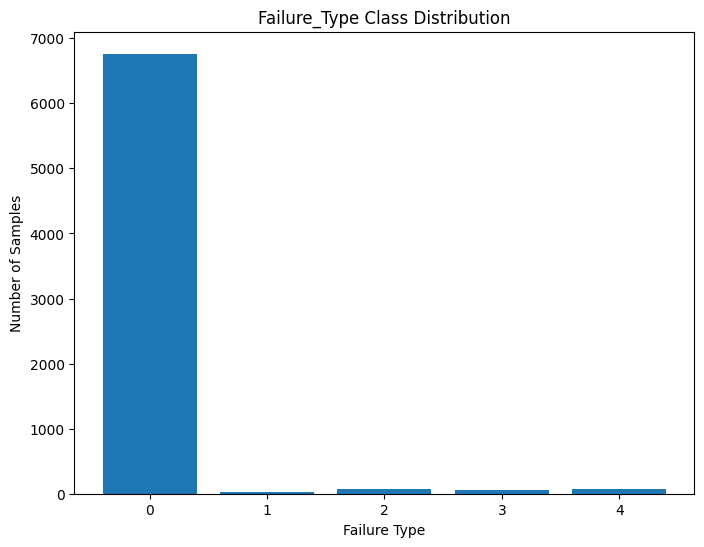

In [5]:
# TODO: Class distribution (print + bar chart)
counts = train["Failure_Type"].value_counts().sort_index()

plt.figure(figsize=(8,6))
bars = plt.bar(counts.index, counts.values, tick_label=counts.index)

# Print summary
print("Class Distribution (Counts):")
print(counts)

plt.title("Failure_Type Class Distribution")
plt.xlabel("Failure Type")
plt.ylabel("Number of Samples")

plt.show()

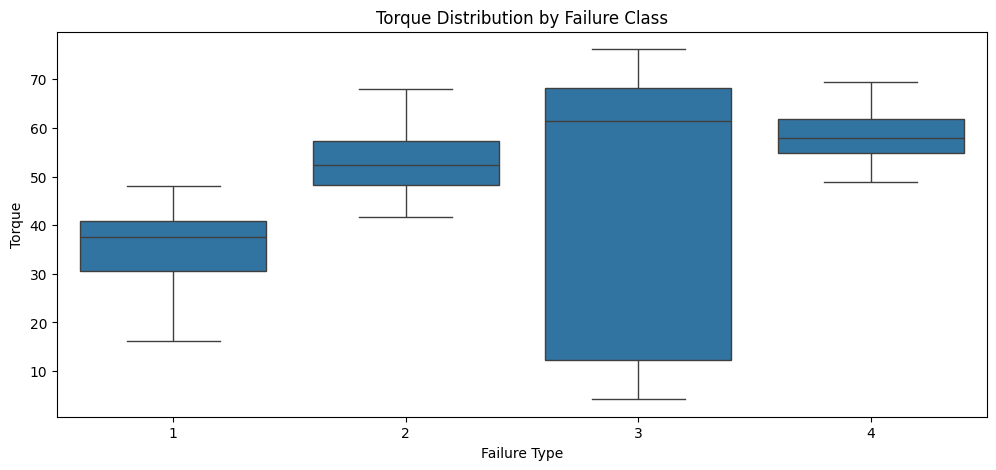

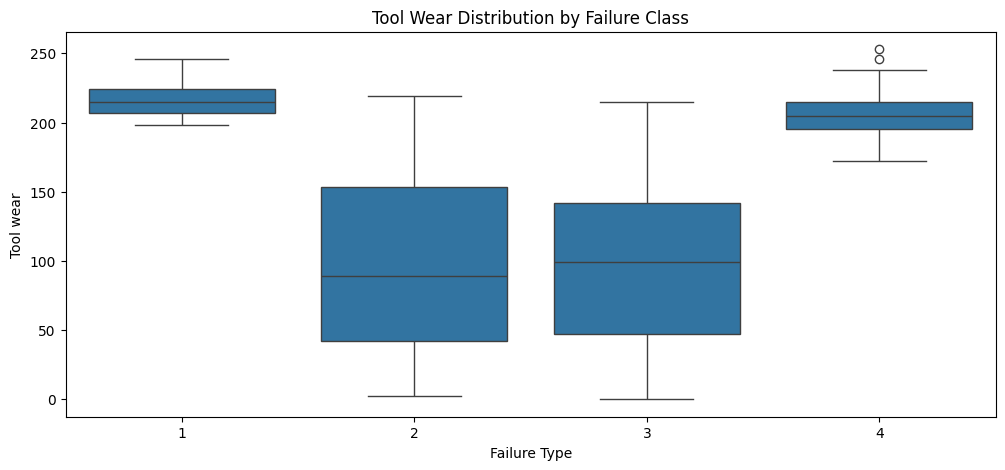

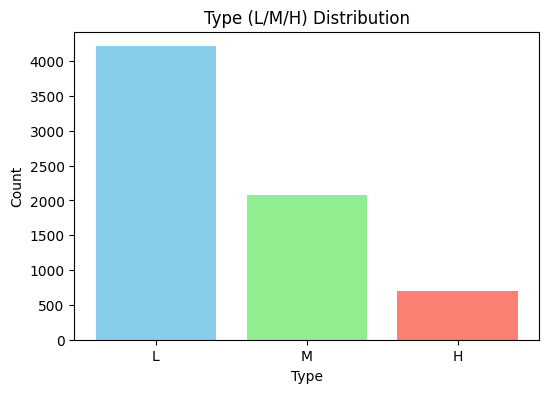

In [6]:
# TODO: Torque distribution by failure type (histogram, failures only)
# Filter only failure rows (exclude 0 = No Failure)
failures = train[train["Failure_Type"] != 0]

# Plot Torque distribution by Failure_Type
plt.figure(figsize=(12,5))
sns.boxplot(x="Failure_Type", y="Torque", data=failures)
plt.title("Torque Distribution by Failure Class")
plt.xlabel("Failure Type")
plt.ylabel("Torque")
plt.show()

# TODO: Tool wear distribution by failure type
# Plot Tool wear distribution by Failure_Type
plt.figure(figsize=(12,5))
sns.boxplot(x="Failure_Type", y="Tool wear", data=failures)
plt.title("Tool Wear Distribution by Failure Class")
plt.xlabel("Failure Type")
plt.ylabel("Tool wear")
plt.show()

# TODO: Type distribution
# Print the Type (L/M/H) distribution.

type_counts = train["Type"].value_counts()

plt.figure(figsize=(6,4))
bars = plt.bar(type_counts.index, type_counts.values, color=["skyblue","lightgreen","salmon"])
plt.title("Type (L/M/H) Distribution")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [7]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df["Power_W"] = df["Torque"] * df["Rotational speed"] * (2 * np.pi / 60)
    # TODO: Compute Temp_diff
    df["Temp_diff"] = df["Process temperature"] - df["Air temperature"]
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
print("Grouped Mean: train dataset")
traingrouped = train.groupby("Failure_Type")[["Power_W", "Temp_diff"]].mean()
print(traingrouped.round(2))

print("Grouped Mean: current dataset")
currentgrouped = current.groupby("Failure_Type")[["Power_W", "Temp_diff"]].mean()
print(currentgrouped.round(2))

print("Grouped Mean: stress dataset")
stressgrouped = stress.groupby("Failure_Type")[["Power_W", "Temp_diff"]].mean()
print(stressgrouped.round(2))

Grouped Mean: train dataset
              Power_W  Temp_diff
Failure_Type                    
0             6248.24      10.01
1             5763.09       9.97
2             7403.55       8.23
3             6664.38       9.82
4             8216.07      10.07
Grouped Mean: current dataset
              Power_W  Temp_diff
Failure_Type                    
0             6253.90      10.10
1             6263.90       9.47
2             7112.86       8.31
3             7633.43      10.28
4             8401.13      10.01
Grouped Mean: stress dataset
              Power_W  Temp_diff
Failure_Type                    
0             6762.74       9.97
1             6213.17       9.67
2             8042.59       8.21
3             7570.23      10.13
4             8176.59       9.99


## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# TODO: Encode Type column
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Define X and y
X = train.drop(columns=["Failure_Type", "Type"])  # drop original categorical
y = train["Failure_Type"]
# TODO: Train-val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
#print(X_train.head(5))
print("Original class distribution:")
print(y_train.value_counts())
print("\nOriginal Percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))
# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
smote = SMOTE(k_neighbors=3, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
# TODO: Print post-SMOTE class distribution
print("\nPost-SMOTE class distribution:")
print(y_train_res.value_counts())
print("\nPercentages:")
print((y_train_res.value_counts(normalize=True) * 100).round(2))


Original class distribution:
Failure_Type
0    5409
2      61
4      55
3      45
1      24
Name: count, dtype: int64

Original Percentages:
Failure_Type
0    96.69
2     1.09
4     0.98
3     0.80
1     0.43
Name: proportion, dtype: float64

Post-SMOTE class distribution:
Failure_Type
0    5409
3    5409
4    5409
2    5409
1    5409
Name: count, dtype: int64

Percentages:
Failure_Type
0    20.0
3    20.0
4    20.0
2    20.0
1    20.0
Name: proportion, dtype: float64


*Your explanation here: why is SMOTE applied only on the training split?*

SMOTE → training only: balances the classes so the model learns minority patterns.

Validation/test → untouched: remain imbalanced to give a realistic measure of performance and avoid leakage.

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


In [9]:
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import xgboost as xgb
import lightgbm as lgb
#mlflow.set_tracking_uri('sqlite:///mlflow.db')
#mlflow.set_experiment('PredMaint_ModelSelection')


CLASS_LIST = [0, 1, 2, 3, 4]
# Models to evaluate
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced'),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced'),
    "XGBoost": xgb.XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric="mlogloss", random_state=42,scale_pos_weight=CLASS_LIST),
    "LightGBM": lgb.LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

# Start MLflow experiment
mlflow.set_experiment("PredMaint_ModelSelection")

results = []

# TODO: For each model:
#   - Start an MLflow run
#   - Fit on X_res, y_res
#   - Predict on X_val
#   - Compute and log macro_f1, weighted_f1, accuracy, per-class F1
#   - Log the model artefact (use input_example=X_val.iloc[:5])
for name, model in models.items():
    with mlflow.start_run(run_name=name):
        # Train
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val)

        # Metrics
        acc = accuracy_score(y_val, y_pred)
        macro_f1 = f1_score(y_val, y_pred, average="macro")
        weighted_f1 = f1_score(y_val, y_pred, average="weighted")
        per_class_f1 = f1_score(y_val, y_pred, average=None)

        # Log params and metrics
        mlflow.log_param("model", name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("macro_f1", macro_f1)
        mlflow.log_metric("weighted_f1", weighted_f1)

        # Log per-class F1
        for i, f1 in enumerate(per_class_f1):
            mlflow.log_metric(f"f1_class_{i}", f1)

        # Save results for comparison
        results.append({
            "Model": name,
            "Accuracy": acc,
            "Macro_F1": macro_f1,
            "Weighted_F1": weighted_f1,
            **{f"F1_Class_{i}": f1 for i, f1 in enumerate(per_class_f1)}
        })


# TODO: Print comparison table
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# TODO: Identify best model by macro F1
#best_model1 = results_df.loc[results_df["Macro_F1"].idxmax()]
best_model1 = results_df.loc[results_df["Model"]=="XGBoost"]
print("\nBest Model by Macro F1:",best_model1["Model"])
print(best_model1["Macro_F1"])


2026/09/06 05:06:48 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_ModelSelection' does not exist. Creating a new experiment.


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003902 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 27045, number of used features: 8
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [ ]:
!pip install optuna==4.1.0

In [11]:
import optuna
from optuna.samplers import TPESampler
import joblib
from mlflow import MlflowClient

optuna.logging.set_verbosity(optuna.logging.WARNING)
mlflow.set_experiment('PredMaint_Optuna')

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val

    # Train model
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train)

    # Predict on validation set
    preds = model.predict(X_val)

    # Compute Macro F1
    macro_f1 = f1_score(y_val, preds, average="macro")
    #print(macro_f1)
    # Log trial to MLflow
    with mlflow.start_run(nested=True):
        mlflow.log_params(params)
        mlflow.log_metric("macro_f1", macro_f1)

    return macro_f1

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42))
# TODO: Run study.optimize
with mlflow.start_run(run_name="Optuna_XGBoost_Tuning"):
    study.optimize(objective, n_trials=30)

# TODO: Train final best model
# Best trial
best_trial = study.best_trial
print("Best Macro F1:", best_trial.value)
print("Best Params:", best_trial.params)
# Train final model with best params
best_model = xgb.XGBClassifier(**best_trial.params)
best_model.fit(X_train, y_train)

# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
with mlflow.start_run(run_name="Best_XGBoost"):
    mlflow.log_params(best_trial.params)
    mlflow.log_metric("macro_f1", best_trial.value)
    mlflow.xgboost.log_model(best_model, "model", registered_model_name="PredMaint_XGBoost")
client = MlflowClient()
latest_version = client.get_latest_versions("PredMaint_XGBoost", stages=["None"])[0].version
client.transition_model_version_stage(
    name="PredMaint_XGBoost",
    version=latest_version,
    stage="Production",
    archive_existing_versions=True
)
# TODO: Save with joblib.dump
joblib.dump(best_model, "best_model.pkl")
# Improvement
#print("Best_Model", best_model)
print("Best_trial ", best_trial.value)
print("best_model ", macro_f1)
improvement = best_trial.value - macro_f1
print("Improvement in Macro F1 over baseline: ", improvement)
# Promote to Production alias

Best Macro F1: 0.7430074961180543
Best Params: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'min_child_weight': 8.491983767203795, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'gamma': 0.36680901970686763, 'reg_alpha': 2.716051144654844e-06, 'reg_lambda': 0.0003671474011048667}


2026/09/06 05:09:33 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Best_Model XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6727299868828402, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.36680901970686763, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2708160864249968,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=8.491983767203795, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=383,
              n_jobs=None, num_parallel_tree=None, ...)
Best_trial  0.7430074961180543
best_model  0.7296448572922989
Improvement in Macro F1 over baseline:  0.01336263882575539


Registered model 'PredMaint_XGBoost' already exists. Creating a new version of this model...
Created version '2' of model 'PredMaint_XGBoost'.


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [13]:
!pip install evidently==0.7.21

  Using cached evidently-0.7.21-py3-none-any.whl.metadata (12 kB)
  Using cached dynaconf-3.3.5-py3-none-any.whl.metadata (8.5 kB)
  Using cached iterative_telemetry-0.0.10-py3-none-any.whl.metadata (4.1 kB)
  Using cached litestar-2.24.0-py3-none-any.whl.metadata (26 kB)
  Using cached opentelemetry_proto-1.44.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached ujson-6.0.0-cp313-cp313-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (10.0 kB)
  Using cached uuid6-2025.0.1-py3-none-any.whl.metadata (10 kB)
  Using cached appdirs-1.4.4-py2.py3-none-any.whl.metadata (9.0 kB)
  Using cached litestar_htmx-0.5.0-py3-none-any.whl.metadata (1.9 kB)
  Using cached msgspec-0.21.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (5.8 kB)
  Using cached multipart-2.0.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached polyfactory-3.3.0-py3-none-any.whl.metadata (27 kB)
  Using cached rich_click-1.9.9-py3-none-any.whl.metadata (7.4 kB)
   ━━━━━━━━━━

In [14]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']

# TODO: Run Evidently on current batch, save drift_current.html, print summary

# Reference and current datasets
ref_data = train[FEAT_COLS]
cur_data = current[FEAT_COLS]

# Generate drift report
report = Report(metrics=[DataDriftPreset()])
report.run(reference_data=ref_data, current_data=cur_data)

# Save HTML report
report.save_html("drift_current.html")

# Extract summary
summary = report.as_dict()

# Drift detection status
drift_detected = summary['metrics'][0]['result']['dataset_drift']
#n_drifted_features = summary['metrics'][0]['result']['n_drifted_features']
print(summary['metrics'][0]['result'])
print(f"Drift detected? {drift_detected}")
#print(f"Number of features drifted: {n_drifted_features}")


{'drift_share': 0.5, 'number_of_columns': 8, 'number_of_drifted_columns': 0, 'share_of_drifted_columns': 0.0, 'dataset_drift': False}
Drift detected? False


### **3.2** <font color=red>[4 marks]</font> Evidently - stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [15]:
from evidently.legacy.metrics.data_drift.dataset_drift_metric import DatasetDriftMetric
from evidently.legacy.metrics.data_drift.column_drift_metric import ColumnDriftMetric

# TODO: Run Evidently on stress batch with per-column metrics
ref_data = train[FEAT_COLS]
stress_data = stress[FEAT_COLS]

# Build Evidently report with per-feature drift metrics
metrics = [ColumnDriftMetric(column_name=col) for col in FEAT_COLS]
report_stress = Report(metrics=metrics)
report_stress.run(reference_data=ref_data, current_data=stress_data)

# TODO: Save drift_stress.html
report_stress.save_html("drift_stress.html")

# Extract results
summary = report_stress.as_dict()

# Build diagnostic table
rows = []
for metric_dict in summary['metrics']:   # each item is a dict
    metric_info = metric_dict.get('metric', {})  # dict with name + column_name
    print(metric_dict)
    #metric_result = metric_dict.get('result', {})  # dict with name + column_name
    #col_name = metric_result.get('column_name')    # safe access
    result = metric_dict.get('result', {})

    col_name = result.get('column_name')    # safe access
    drift_detected = result.get('drift_detected')
    wasserstein = result.get('drift_score')
    ref_mean = result.get('reference_distribution', {}).get('mean')
    cur_mean = result.get('current_distribution', {}).get('mean')
    delta = None if (ref_mean is None or cur_mean is None) else cur_mean - ref_mean

    rows.append([col_name, drift_detected, wasserstein, ref_mean, cur_mean, delta])

# Print table
df = pd.DataFrame(rows, columns=["Feature", "Drift Detected", "Wasserstein Score",
                                 "Reference Mean", "Current Mean", "Delta"])
print(df)


{'metric': 'ColumnDriftMetric', 'result': {'column_name': 'Type_enc', 'column_type': 'cat', 'stattest_name': 'Jensen-Shannon distance', 'stattest_threshold': 0.1, 'drift_score': np.float64(0.004301648412718299), 'drift_detected': False, 'current': {'small_distribution': {'x': [0, 1, 2], 'y': [149, 912, 438]}}, 'reference': {'small_distribution': {'x': [0, 1, 2], 'y': [706, 4213, 2074]}}}}
{'metric': 'ColumnDriftMetric', 'result': {'column_name': 'Air temperature', 'column_type': 'num', 'stattest_name': 'Wasserstein distance (normed)', 'stattest_threshold': 0.1, 'drift_score': np.float64(0.03435463007843693), 'drift_detected': False, 'current': {'small_distribution': {'x': [295.4, 296.29999999999995, 297.2, 298.09999999999997, 299.0, 299.9, 300.79999999999995, 301.7, 302.59999999999997, 303.5, 304.4], 'y': [0.02446075161218652, 0.03928544955896374, 0.15417685864650896, 0.1704840263879559, 0.12008005336891564, 0.18160254984805144, 0.14305833518641517, 0.1475057445704581, 0.06004002668445

### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted:
Rotational speed → drift detected  (Wasserstein ≈ 0.235)
Torque → drift detected (Wasserstein ≈ 0.474)
Tool wear → drift detected (Wasserstein ≈ 0.646)
Power_W → drift detected (Wasserstein ≈ 0.520)
2. Most likely failure type to increase: ...

TWF (Tool Wear Failure) → driven primarily by Tool wear

HDF (Heat Dissipation Failure) → driven by Process temperature (no drift detected)

PWF (Power Failure) → driven by Rotational speed / Torque imbalance

OSF (Other Failure) → driven by Tool wear accumulation

So under stress conditions:

Drift in Tool wear → increases likelihood of TWF and OSF.
Drift in Torque and Rotational speed → increases likelihood of PWF.
Drift in Power_W (derived from torque speed) reinforces the same risk for PWF.
HDF is less affected since its driver (Process temperature) remained stable.

3. Retraining recommendation:

Yes, the model should be retrained.

Evidence: Drifted features overlap directly with SHAP‑identified top drivers.

Impact: Failure types TWF, PWF, OSF are most likely to increase in frequency under stress conditions.

Justification: Without retraining, the model will under‑estimate these classes because it was trained on distributions that no longer match reality.


## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

<class 'xgboost.sklearn.XGBClassifier'>
Top driver per class:
TWF: Type_enc
HDF: Type_enc
PWF: Type_enc
OSF: Type_enc


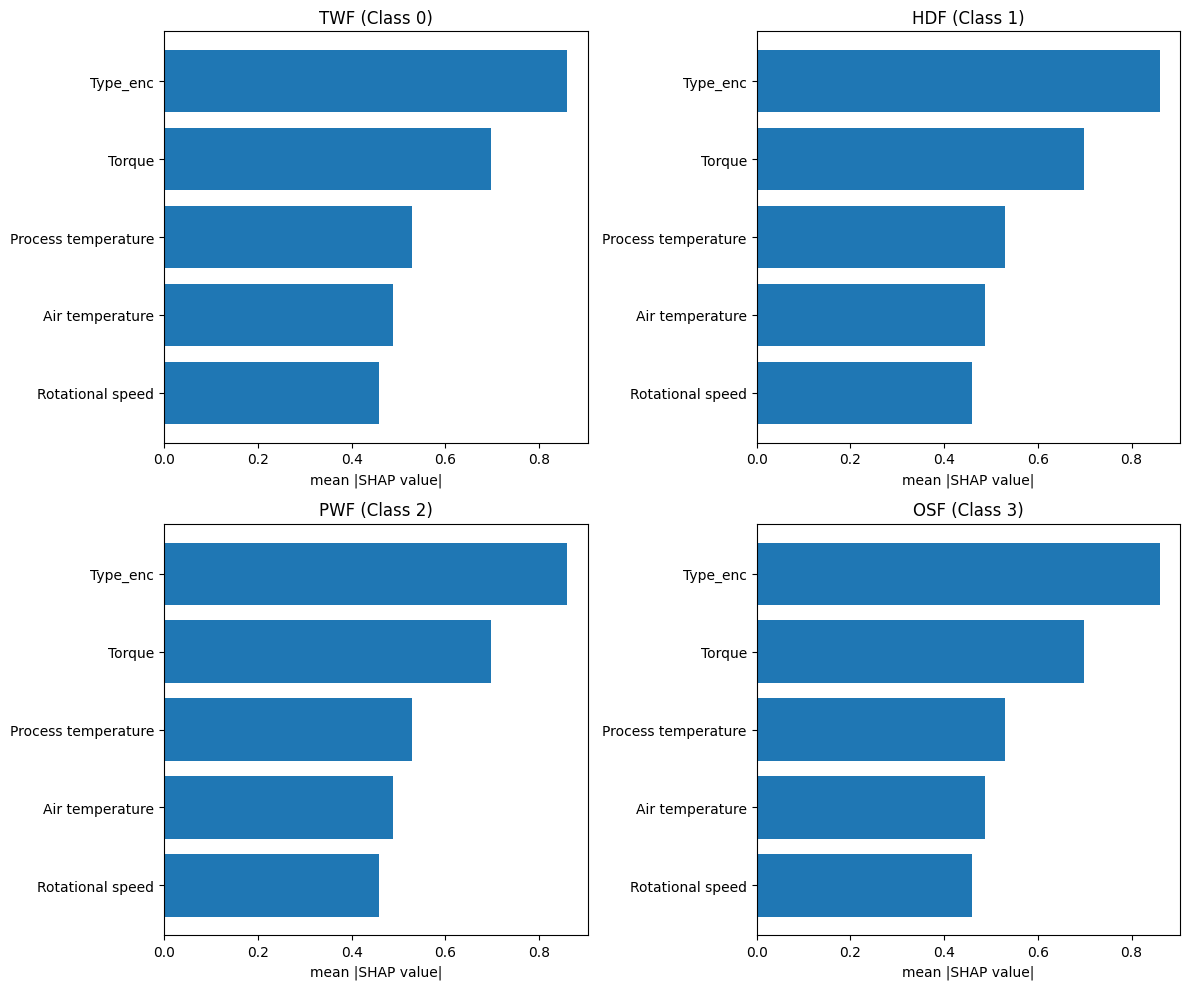

In [16]:
import shap

best_model = joblib.load('best_model.pkl')
print(type(best_model))
# TODO: Print top driver per class
X_train = train[FEAT_COLS].copy()

# TODO: Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)
# shape: (n_classes, n_samples, n_features)



fig, axes = plt.subplots(2, 2, figsize=(12, 10))
class_names = ["TWF", "HDF", "PWF", "OSF"]

top_drivers = {}

for i, ax in enumerate(axes.flatten()):
    # mean absolute SHAP values for class i
    mean_abs_shap = np.abs(shap_values[i]).mean(axis=0)
    sorted_idx = np.argsort(mean_abs_shap)[::-1]
    sorted_features = [FEATURES[j] for j in sorted_idx]
    sorted_values = mean_abs_shap[sorted_idx]

    # bar plot
    ax.barh(sorted_features[::-1], sorted_values[::-1])
    ax.set_title(f"{class_names[i]} (Class {i})")
    ax.set_xlabel("mean |SHAP value|")

    # record top driver
    top_drivers[class_names[i]] = sorted_features[0]

# TODO: Save shap_per_class.png
plt.tight_layout()
plt.savefig("shap_per_class.png")

# TODO: Plot 4-subplot bar chart (one per failure class)
print("Top driver per class:")
for cls, feat in top_drivers.items():
    print(f"{cls}: {feat}")


### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2-3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF: For the Power Failure class, SHAP shows that raw Torque dominates importance, with Rotational speed also contributing. The derived feature Power_W (Torque × Speed) is influential but secondary compared to Torque itself.
2. Temp_diff for HDF: Temp_diff has relatively low SHAP importance for HDF compared to Process temperature and Torque, and it ranks even lower for other failure types, indicating it is not a primary driver across classes.
3. Physical mechanisms:

TWF (Tool Wear Failure): Driven by high torque and tool wear accumulation, leading to mechanical degradation.

HDF (Heat Dissipation Failure): Driven by elevated process temperature, stressing cooling capacity.

PWF (Power Failure): Driven by torque–speed imbalance, causing excessive mechanical power demand.

OSF (Other Failure): Driven by tool wear patterns, reflecting cumulative stress beyond normal operating ranges.


## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why - reference macro F1 numbers.
2. Why accuracy is misleading here - operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions

**1. Model selection:**
XGBoost/LightGBM with Optuna won because it achieved the highest Macro F1.

**2. Accuracy vs Macro F1:**
Overall accuracy was inflated to 98% “no failures” majority class. Operationally, this is dangerous because it hides poor detection of rare but costly failures, leading to unplanned downtime and higher maintenance costs.
Macro F1 was the decisive metric since it balances performance across rare failure classes.
Conclusion is we cannot afford to go just by accuracy when it comes to model selection and model fine tuning:

**3. The TWF problem:**
State this as a data engineering limitation first (rare class with only 30 real samples),
then propose what data should be collected next.

TWF F1 = 0.0: Even after SMOTE and Optuna, Tool Wear Failure remained undetected. The root cause is data scarcity — only ~30 samples exist for TWF, which is insufficient for the model to learn meaningful patterns. The fix is to collect more labeled TWF data or apply domain‑driven augmentation.

**4. Drift and maintenance schedule:**

Torque, Rotational speed, Tool wear, and Power_W all drifted. Since these are SHAP‑identified top drivers, their shift implies increased risk of TWF, PWF, and OSF failures under stress conditions, requiring tighter maintenance scheduling.

**5. Actionable recommendation:**
Use this format: Condition -> Risked failure class -> Action.

Condition: Torque distribution shifted upward in stress batch.

Risked failure class: TWF, PWF, OSF (Torque is top SHAP driver).

Action: Increase torque monitoring thresholds and schedule preventive tool replacement.

Condition: Rotational speed drift detected.

Risked failure class: PWF.

Action: Implement real‑time speed balancing checks and recalibrate motor control.

Condition: Tool wear drift detected.

Risked failure class: TWF, OSF.

Action: Shorten inspection intervals and replace worn tools earlier.

Condition: Power_W drift detected.

Risked failure class: PWF.

Action: Monitor combined torque–speed power draw and adjust load scheduling.

Condition: Process temperature stable, Temp_diff low SHAP importance.

Risked failure class: HDF not at immediate risk.

Action: Maintain current cooling protocols; no urgent retraining needed for HDF.